# Backgrounds Challenge — Fine-tuning ResNet-50 avec Mixup
Fine-tune ResNet-50 on IN-9 with Mixup augmentation, then compare BG-Gap vs baseline (7.4%).

In [1]:
# Cell 1 — Imports & device
import json
import time
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision import transforms, datasets
from torchvision.models import resnet50, ResNet50_Weights
from torch.utils.data import DataLoader

device = "cuda:0" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(f"{torch.__version__=}")
print(f"Using {device=}")

torch.__version__='2.10.0+cu128'
Using device='cuda:0'


In [2]:
# Cell 2 — Mount Google Drive + copie locale pour accélérer le chargement
import shutil, os
from google.colab import drive
drive.mount('/content/drive')

DRIVE_PATH = "/content/drive/MyDrive/in9"
TRAIN_PATH = "/content/in9"

if not os.path.exists(TRAIN_PATH):
    print("Copie de in9/ depuis Drive vers /content/ (une seule fois)...")
    t0 = time.time()
    shutil.copytree(DRIVE_PATH, TRAIN_PATH)
    print(f"Copie terminée en {time.time()-t0:.0f}s")
else:
    print("in9/ déjà présent localement, copie ignorée.")

print(f"Train data path: {TRAIN_PATH}")

Mounted at /content/drive
Copie de in9/ depuis Drive vers /content/ (une seule fois)...
Copie terminée en 345s
Train data path: /content/in9


In [3]:
# Cell 3 — Download test data (bg_challenge)
!wget -q "https://github.com/MadryLab/backgrounds_challenge/releases/download/data/backgrounds_challenge_data.tar.gz"
!tar -xzf backgrounds_challenge_data.tar.gz
!ls bg_challenge/

fg_mask     mixed_rand	no_fg	   only_bg_t  original
mixed_next  mixed_same	only_bg_b  only_fg


In [4]:
# Cell 4 — Classes IN-9
IN9_CLASSES = ['Dog', 'Bird', 'Vehicle', 'Reptile', 'Carnivore', 'Insect', 'Instrument', 'Primate', 'Fish']
NUM_CLASSES = len(IN9_CLASSES)
print(f"IN-9 classes ({NUM_CLASSES}): {IN9_CLASSES}")

IN-9 classes (9): ['Dog', 'Bird', 'Vehicle', 'Reptile', 'Carnivore', 'Insect', 'Instrument', 'Primate', 'Fish']


In [5]:
# Cell 5 — Transforms
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

print("Transforms defined.")

Transforms defined.


In [6]:
# Cell 6 — DataLoaders
train_ds = datasets.ImageFolder(f"{TRAIN_PATH}/train", transform=train_transform)
val_ds   = datasets.ImageFolder(f"{TRAIN_PATH}/val",   transform=val_transform)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train: {len(train_ds)} images, {len(train_loader)} batches")
print(f"Val:   {len(val_ds)} images, {len(val_loader)} batches")
print(f"Classes: {train_ds.classes}")

Train: 12364 images, 194 batches
Val:   1420 images, 23 batches
Classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8']


In [7]:
# Cell 7 — Modèle ResNet-50 fine-tuné sur 9 classes
model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
model = model.to(device)
print(f"Model: ResNet-50, fc: {model.fc}")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:02<00:00, 41.4MB/s]


Model: ResNet-50, fc: Linear(in_features=2048, out_features=9, bias=True)


In [8]:
# Cell 8 — Mixup helpers
def mixup_data(x, y, alpha=0.2):
    """Returns mixed inputs, pairs of targets, and lambda."""
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    idx = torch.randperm(x.size(0)).to(device)
    mixed_x = lam * x + (1 - lam) * x[idx]
    y_a, y_b = y, y[idx]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

print("Mixup helpers defined.")

Mixup helpers defined.


In [9]:
# Cell 9 — Optimizer, scheduler, criterion + train/val functions
EPOCHS = 10
MIXUP_ALPHA = 0.2

optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = nn.CrossEntropyLoss()

def train_epoch(model, loader):
    model.train()
    total_loss = 0.0
    n_batches = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        mixed_x, y_a, y_b, lam = mixup_data(images, labels, alpha=MIXUP_ALPHA)
        outputs = model(mixed_x)
        loss = mixup_criterion(criterion, outputs, y_a, y_b, lam)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        n_batches += 1
    return total_loss / n_batches

def eval_epoch(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total

print(f"Training setup: {EPOCHS} epochs, lr=0.01, Mixup alpha={MIXUP_ALPHA}")

Training setup: 10 epochs, lr=0.01, Mixup alpha=0.2


In [10]:
# Cell 10 — Boucle d'entraînement principale
history = {'train_loss': [], 'val_acc': []}

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    train_loss = train_epoch(model, train_loader)
    val_acc    = eval_epoch(model, val_loader)
    scheduler.step()
    elapsed = time.time() - t0

    history['train_loss'].append(train_loss)
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch:2d}/{EPOCHS} | loss: {train_loss:.4f} | val_acc: {val_acc*100:.2f}% | {elapsed:.0f}s")

# Save checkpoint to Drive
CKPT_PATH = "/content/drive/MyDrive/resnet50_mixup_in9.pth"
torch.save(model.state_dict(), CKPT_PATH)
print(f"\nCheckpoint saved to {CKPT_PATH}")

Epoch  1/10 | loss: 0.7773 | val_acc: 88.87% | 128s
Epoch  2/10 | loss: 0.6839 | val_acc: 87.46% | 141s
Epoch  3/10 | loss: 0.6558 | val_acc: 92.39% | 142s
Epoch  4/10 | loss: 0.5552 | val_acc: 94.01% | 141s
Epoch  5/10 | loss: 0.5883 | val_acc: 96.20% | 141s
Epoch  6/10 | loss: 0.5418 | val_acc: 94.44% | 141s
Epoch  7/10 | loss: 0.4685 | val_acc: 96.27% | 139s
Epoch  8/10 | loss: 0.4864 | val_acc: 96.13% | 141s
Epoch  9/10 | loss: 0.4689 | val_acc: 96.20% | 139s
Epoch 10/10 | loss: 0.4829 | val_acc: 96.55% | 141s

Checkpoint saved to /content/drive/MyDrive/resnet50_mixup_in9.pth


In [11]:
# Cell 11 — Évaluation sur IN-9 test sets (bg_challenge)
# Le modèle fine-tuné prédit directement en 9 classes → pas de mapping in_to_in9 nécessaire

def evaluate(variation, data_root="bg_challenge", batch_size=64):
    dataset = datasets.ImageFolder(f"{data_root}/{variation}/val", transform=val_transform)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=2)

    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, targets in loader:
            images = images.to(device)
            outputs = model(images)
            preds = outputs.argmax(dim=1).cpu()
            correct += (preds == targets).sum().item()
            total += targets.size(0)
    return correct / total

variations = ["original", "mixed_same", "mixed_rand", "only_fg", "no_fg", "only_bg_t", "only_bg_b"]
results_mixup = {}

for var in variations:
    t0 = time.time()
    acc = evaluate(var)
    results_mixup[var] = acc
    print(f"{var:15s}: {acc*100:.1f}%  ({time.time()-t0:.0f}s)")

bg_gap_mixup = (results_mixup['mixed_same'] - results_mixup['mixed_rand']) * 100
print(f"\nBG-Gap (Mixup): {bg_gap_mixup:.1f}%")

original       : 95.9%  (16s)
mixed_same     : 91.6%  (16s)
mixed_rand     : 80.4%  (16s)
only_fg        : 90.0%  (15s)
no_fg          : 52.6%  (16s)
only_bg_t      : 41.8%  (16s)
only_bg_b      : 29.9%  (16s)

BG-Gap (Mixup): 11.1%


=== COMPARAISON BASELINE vs MIXUP ===
Variation       |   Baseline |      Mixup |    Delta
----------------------------------------------------
original        |      95.5% |      95.9% | +   0.4%
mixed_same      |      86.2% |      91.6% | +   5.4%
mixed_rand      |      78.9% |      80.4% | +   1.5%
only_fg         |      86.6% |      90.0% | +   3.4%
no_fg           |      46.2% |      52.6% | +   6.4%
only_bg_t       |      15.9% |      41.8% | +  25.9%
only_bg_b       |      11.6% |      29.9% | +  18.3%
----------------------------------------------------
BG-Gap          |       7.3% |      11.1% |    +3.8%


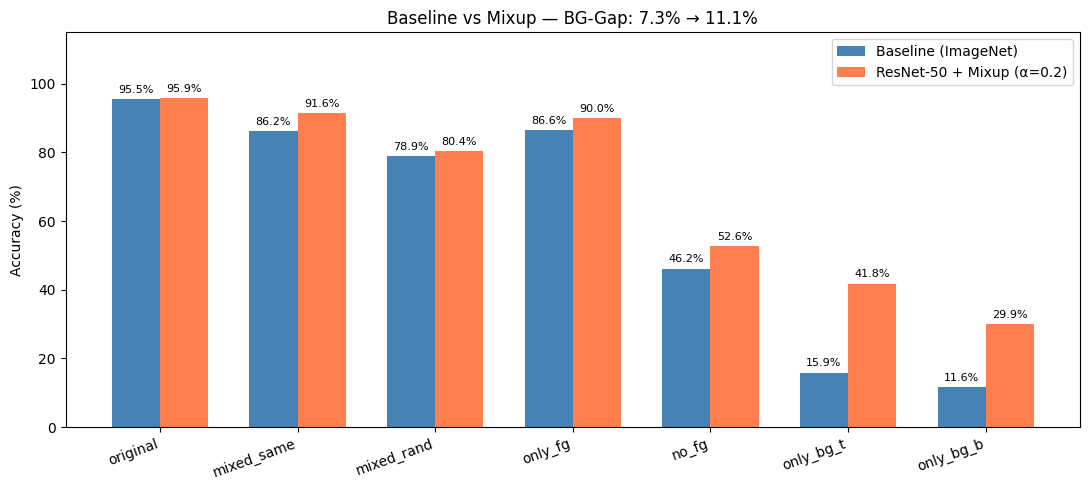

Figure saved.


In [12]:
# Cell 12 — Comparaison baseline vs Mixup

# Baseline results from baseline.ipynb
results_baseline = {
    'original':   0.955,
    'mixed_same': 0.862,
    'mixed_rand': 0.789,
    'only_fg':    0.866,
    'no_fg':      0.462,
    'only_bg_t':  0.159,
    'only_bg_b':  0.116,
}
bg_gap_baseline = (results_baseline['mixed_same'] - results_baseline['mixed_rand']) * 100

print("=== COMPARAISON BASELINE vs MIXUP ===")
print(f"{'Variation':15s} | {'Baseline':>10s} | {'Mixup':>10s} | {'Delta':>8s}")
print("-" * 52)
for var in variations:
    b = results_baseline[var] * 100
    m = results_mixup[var] * 100
    delta = m - b
    sign = '+' if delta >= 0 else ''
    print(f"{var:15s} | {b:>9.1f}% | {m:>9.1f}% | {sign}{delta:>6.1f}%")
print("-" * 52)
print(f"{'BG-Gap':15s} | {bg_gap_baseline:>9.1f}% | {bg_gap_mixup:>9.1f}% | {bg_gap_mixup - bg_gap_baseline:>+7.1f}%")

# Bar chart côte à côte
x = np.arange(len(variations))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
bars1 = ax.bar(x - width/2, [results_baseline[v]*100 for v in variations], width,
               label='Baseline (ImageNet)', color='steelblue')
bars2 = ax.bar(x + width/2, [results_mixup[v]*100 for v in variations], width,
               label=f'ResNet-50 + Mixup (α={MIXUP_ALPHA})', color='coral')

ax.bar_label(bars1, fmt='%.1f%%', padding=3, fontsize=8)
ax.bar_label(bars2, fmt='%.1f%%', padding=3, fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(variations, rotation=20, ha='right')
ax.set_ylim(0, 115)
ax.set_ylabel('Accuracy (%)')
ax.set_title(f'Baseline vs Mixup — BG-Gap: {bg_gap_baseline:.1f}% → {bg_gap_mixup:.1f}%')
ax.legend()
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/baseline_vs_mixup.png", dpi=150)
plt.show()
print("Figure saved.")